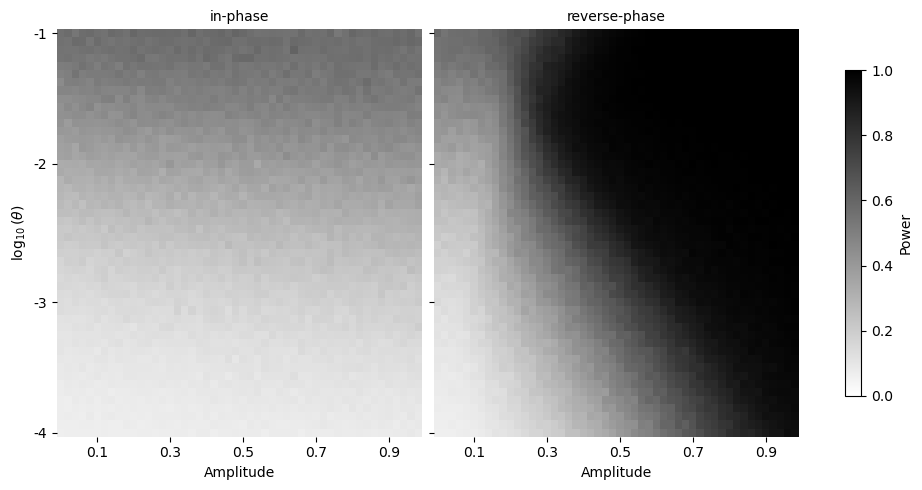

In [24]:
# Cell 0: Power Heatmap (sync vs async)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

df = pd.read_csv("outputs/crlb.csv", index_col=None)
df = df.rename(columns={'delta': 'amplitude'})
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['crlb'] = df.crlb / np.sqrt(20)
df['log_crlb'] = np.log10(df.crlb)
df['log_theta'] = np.log10(df.theta)

z_alpha = 1.645
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] / df['crlb'])
df_agg = df.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

g = sns.FacetGrid(df_agg, col='phase2', height=5, aspect=1)
g.map_dataframe(draw_heatmap)
g.set_axis_labels('Amplitude', r'$\log_{10}(\theta)$')
g.set_titles(col_template='{col_name}')
sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(0, 1))
sm.set_array([])
g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8, label='Power')
plt.savefig("pix/power.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/power.pdf", bbox_inches='tight')
plt.show()

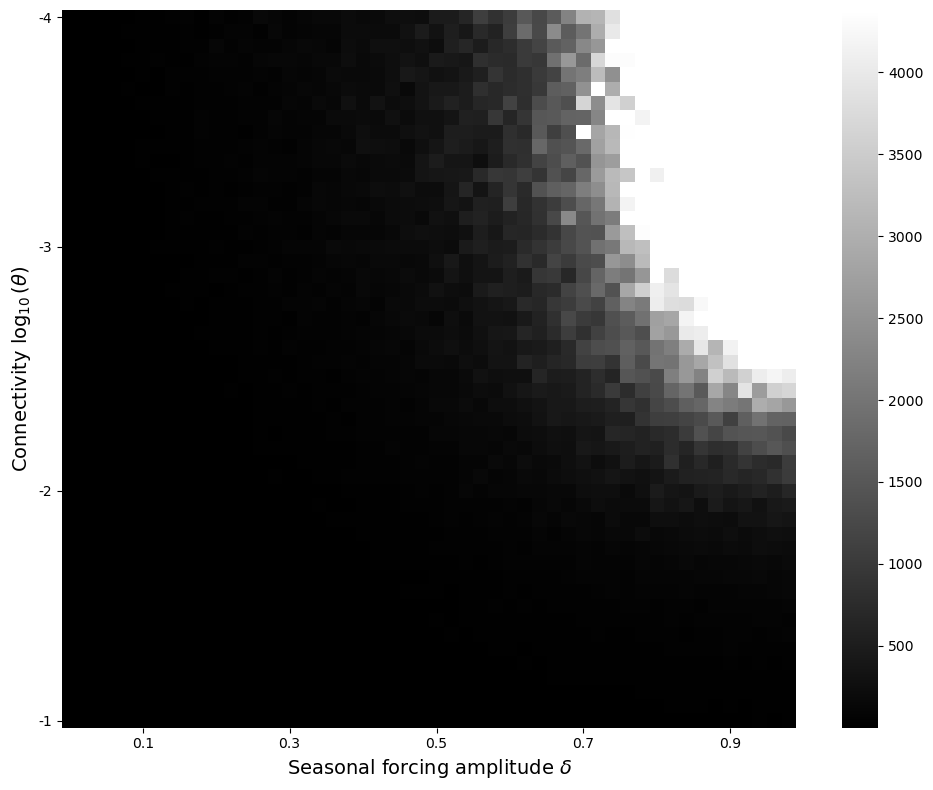

In [25]:
# Cell 1: CRLB Ratio Heatmap (sync / unsync)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

def median_ratio(pp):
    sync = pp.query("phase2 == 0").crlb.values
    unsync = pp.query("phase2 > 0").crlb.values
    ret =  np.median(sync) / np.median(unsync)
    return ret

    
df = pd.read_csv("outputs/crlb.csv")
df = df.rename(columns={'delta': 'amplitude'})
groups = list(df.groupby(['amplitude', 'theta']))
results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for name, group in groups)
index = pd.MultiIndex.from_tuples([name for name, group in groups], names=['amplitude', 'theta'])
agg = pd.Series(results, index=index)

heat = agg.unstack(level='amplitude')
heat.index = np.log10(heat.index)
vmax = np.percentile(heat.values.flatten(), 90)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False, vmin=1, vmax=vmax)
amplitudes = heat.columns.values
thetas = heat.index.values
x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
ax.set_xticks(x_positions)
ax.set_xticklabels(x_desired)
y_desired = [-1, -2, -3, -4]
y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_desired)
plt.ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=14)
plt.xlabel(r'Seasonal forcing amplitude $\delta$', fontsize=14)
plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150)
plt.savefig("pix/crlb_ratio.pdf")
plt.show()

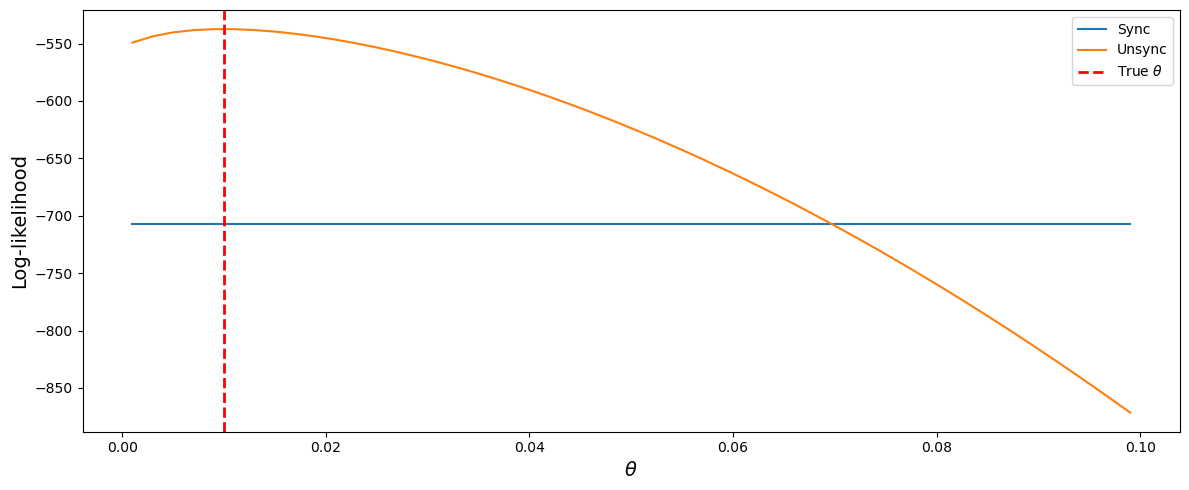

In [53]:
# Cell 2: Profile Likelihood Surface (sync vs unsync)
# For each set of initial conditions, sweep theta over a grid and compute log-likelihood.
# Same data and same ICs across all theta values -> smooth curves.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import flu, losses
from src.packer import Packer

N_POP = 1e7
disease = flu.Mortality
regions = ["A", "B"]
n_season = 20
seasons = list(range(n_season))
thetas =  np.linspace(0.001, 0.099, 50)
populations = {(s, r): N_POP for s in seasons for r in regions}
packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
true = dict(I_init=np.ones((n_season,2))*np.random.uniform(100), S_init=np.ones((n_season,2))*np.random.uniform(8e6,9e6), theta=0)
theta = 0.01
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

phases = [0, np.pi/4, np.pi/2, np.pi]
labels = ["Sync", r"$\pi / 4$", r"$\pi / 2$", "Unsync"]
for i, (phase2, label) in  enumerate(zip(phases, labels)):
    phase = np.array([0.0, phase2])
    if i in [1,2]:
        continue
    true['theta'] = theta
    obs = packer.sim(true, phase, disease)
    mu = obs['mu']
    scale = np.sqrt(disease.rho * (1 - disease.rho) * mu) 
    obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * scale

        
    lls = []
    for th in thetas:
        true['theta'] = th
        sim = packer.sim(true, phase, disease)
        ll = losses.gaussian(obs, sim, rho=disease.rho)
        lls.append(-ll)
    ax.plot(thetas, lls, label=label)

ax.axvline(x=theta, color='red', linestyle='--', linewidth=2, label=r'True $\theta$')
ax.set_xlabel(r"$\theta$", fontsize=14)
ax.set_ylabel("Log-likelihood", fontsize=14)
ax.legend()

plt.tight_layout()
plt.savefig("pix/likelihood_surface.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/likelihood_surface.pdf", bbox_inches='tight')
plt.show()

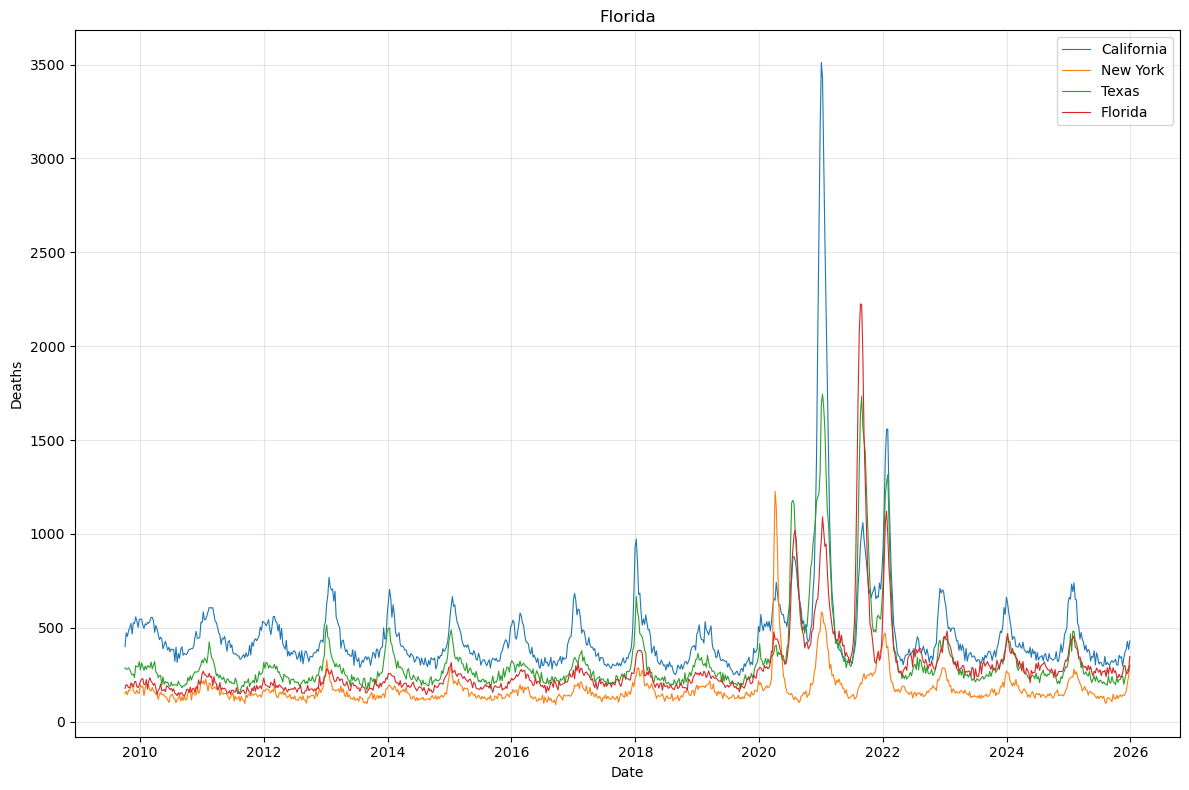

In [54]:
# Cell 3: Raw P&I Death Counts for Representative States
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
df = df[df["state"].isin(states)].sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharex=True)
for state in states:
    dd = df[df["state"] == state]
    ax.plot(dd["date"], dd["deaths"], linewidth=0.8, label=state)
    ax.set_ylabel("Deaths")
    ax.set_title(state)
    ax.grid(True, alpha=0.3)


ax.set_xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig("pix/raw_deaths.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/raw_deaths.pdf", bbox_inches='tight')
plt.show()

In [59]:
# Cell 4: Fitted vs Observed Deaths for a State Pair
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from src import compute_g
from src.flu import Mortality as flu
from src.data_loader import load_real

# Pick a state pair with results
results_files = sorted(glob("outputs/states/*.csv"))
if results_files:
    res = pd.read_csv(results_files[0])
    s1, s2 = res.iloc[0]['state1'], res.iloc[0]['state2']

    import us
    regions = [us.states.lookup(s1).name, us.states.lookup(s2).name]
    seasons = res['season'].unique().tolist()

    obs, phase = load_real(disease=flu, regions=regions, seasons=seasons)

    pop_df = pd.read_csv("data/pni_mortality/populations.csv", parse_dates=["date"])
    pop_df['season'] = pop_df['date'].dt.year + 1
    pop_df = pop_df[['season', 'state', 'population']].set_index(['season', 'state'])

    # Simulate with fitted parameters for first season
    row = res.iloc[0]
    season = int(row['season'])
    N = np.array([pop_df.loc[(season, regions[0]), 'population'],
                  pop_df.loc[(season, regions[1]), 'population']])
    Ts = season + np.arange(flu.n_weeks) * flu.step_size

    fit_traj = compute_g.contacts(
        S0=np.array([row['S1_0'], row['S2_0']]),
        I0=np.array([row['I1_0'], row['I2_0']]),
        gamma=flu.gamma, theta=row['theta'], Ts=Ts,
        beta0=flu.beta0, delta=flu.delta, phase=phase, N=N
    ).reset_index()

    season_obs = obs[obs['season'] == season]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for j, region in enumerate(regions):
        ax = axes[j]
        obs_r = season_obs[season_obs['region'] == region].sort_values('t')
        fit_r = fit_traj[fit_traj['j'] == j]

        ax.plot(obs_r['t'], obs_r['incidence'], 'ko', markersize=4, label='Observed')
        ax.plot(fit_r['t'], fit_r['mu'] * flu.rho, 'r-', linewidth=2, label=r'Fitted $\rho\mu$')
        ax.set_title(f"{region}")
        ax.set_xlabel('t')
        ax.set_ylabel('Deaths')
        ax.legend()

    fig.suptitle(f"Season {season}, $\\hat{{\\theta}}$={row['theta']:.4f}")
    plt.tight_layout()
    plt.savefig("pix/fitted_vs_observed.png", dpi=150, bbox_inches='tight')
    plt.savefig("pix/fitted_vs_observed.pdf", bbox_inches='tight')
    plt.show()
else:
    print("No results files found in outputs/states/")

SyntaxError: invalid syntax (3294253139.py, line 9)

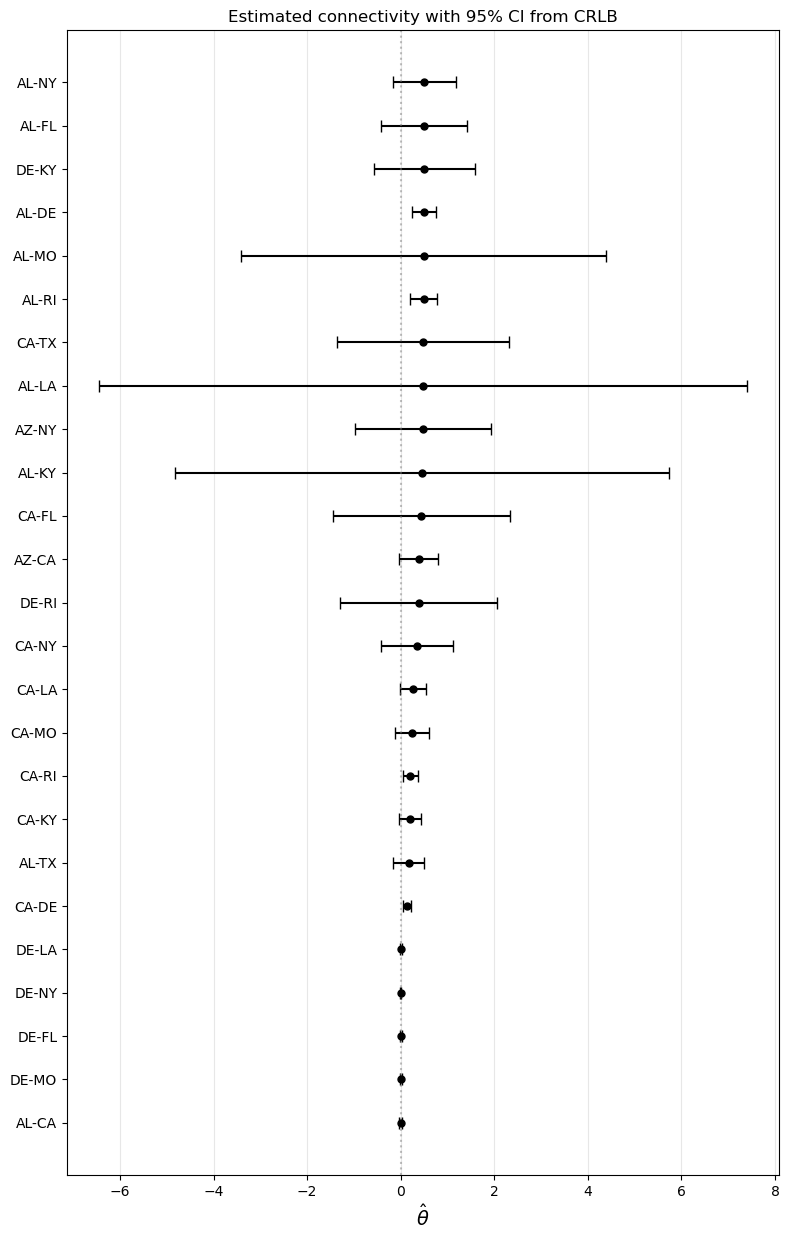

In [56]:
# Cell 5: Theta Estimates with CRLB Confidence Intervals (forest plot)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

files = sorted(glob("outputs/states/*.csv"))
if files:
    all_res = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    # One row per state pair: aggregate CRLB across seasons
    pairs = []
    for (s1, s2), grp in all_res.groupby(['state1', 'state2']):
        theta = grp['theta'].iloc[0]
        crlb_std = np.sqrt(1 / np.sum(1 / grp['crlb']))
        pairs.append({'pair': f"{s1}-{s2}", 'theta': theta, 'crlb_std': crlb_std})
    pairs = pd.DataFrame(pairs).sort_values('theta')

    fig, ax = plt.subplots(figsize=(8, max(4, len(pairs) * 0.5)))
    y = range(len(pairs))
    ax.errorbar(pairs['theta'], y, xerr=1.96 * pairs['crlb_std'],
                fmt='ko', capsize=4, markersize=5)
    ax.set_yticks(list(y))
    ax.set_yticklabels(pairs['pair'])
    ax.set_xlabel(r'$\hat{\theta}$', fontsize=14)
    ax.set_title(r'Estimated connectivity with 95% CI from CRLB')
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig("pix/theta_estimates.png", dpi=150, bbox_inches='tight')
    plt.savefig("pix/theta_estimates.pdf", bbox_inches='tight')
    plt.show()
else:
    print("No results files found in outputs/states/")

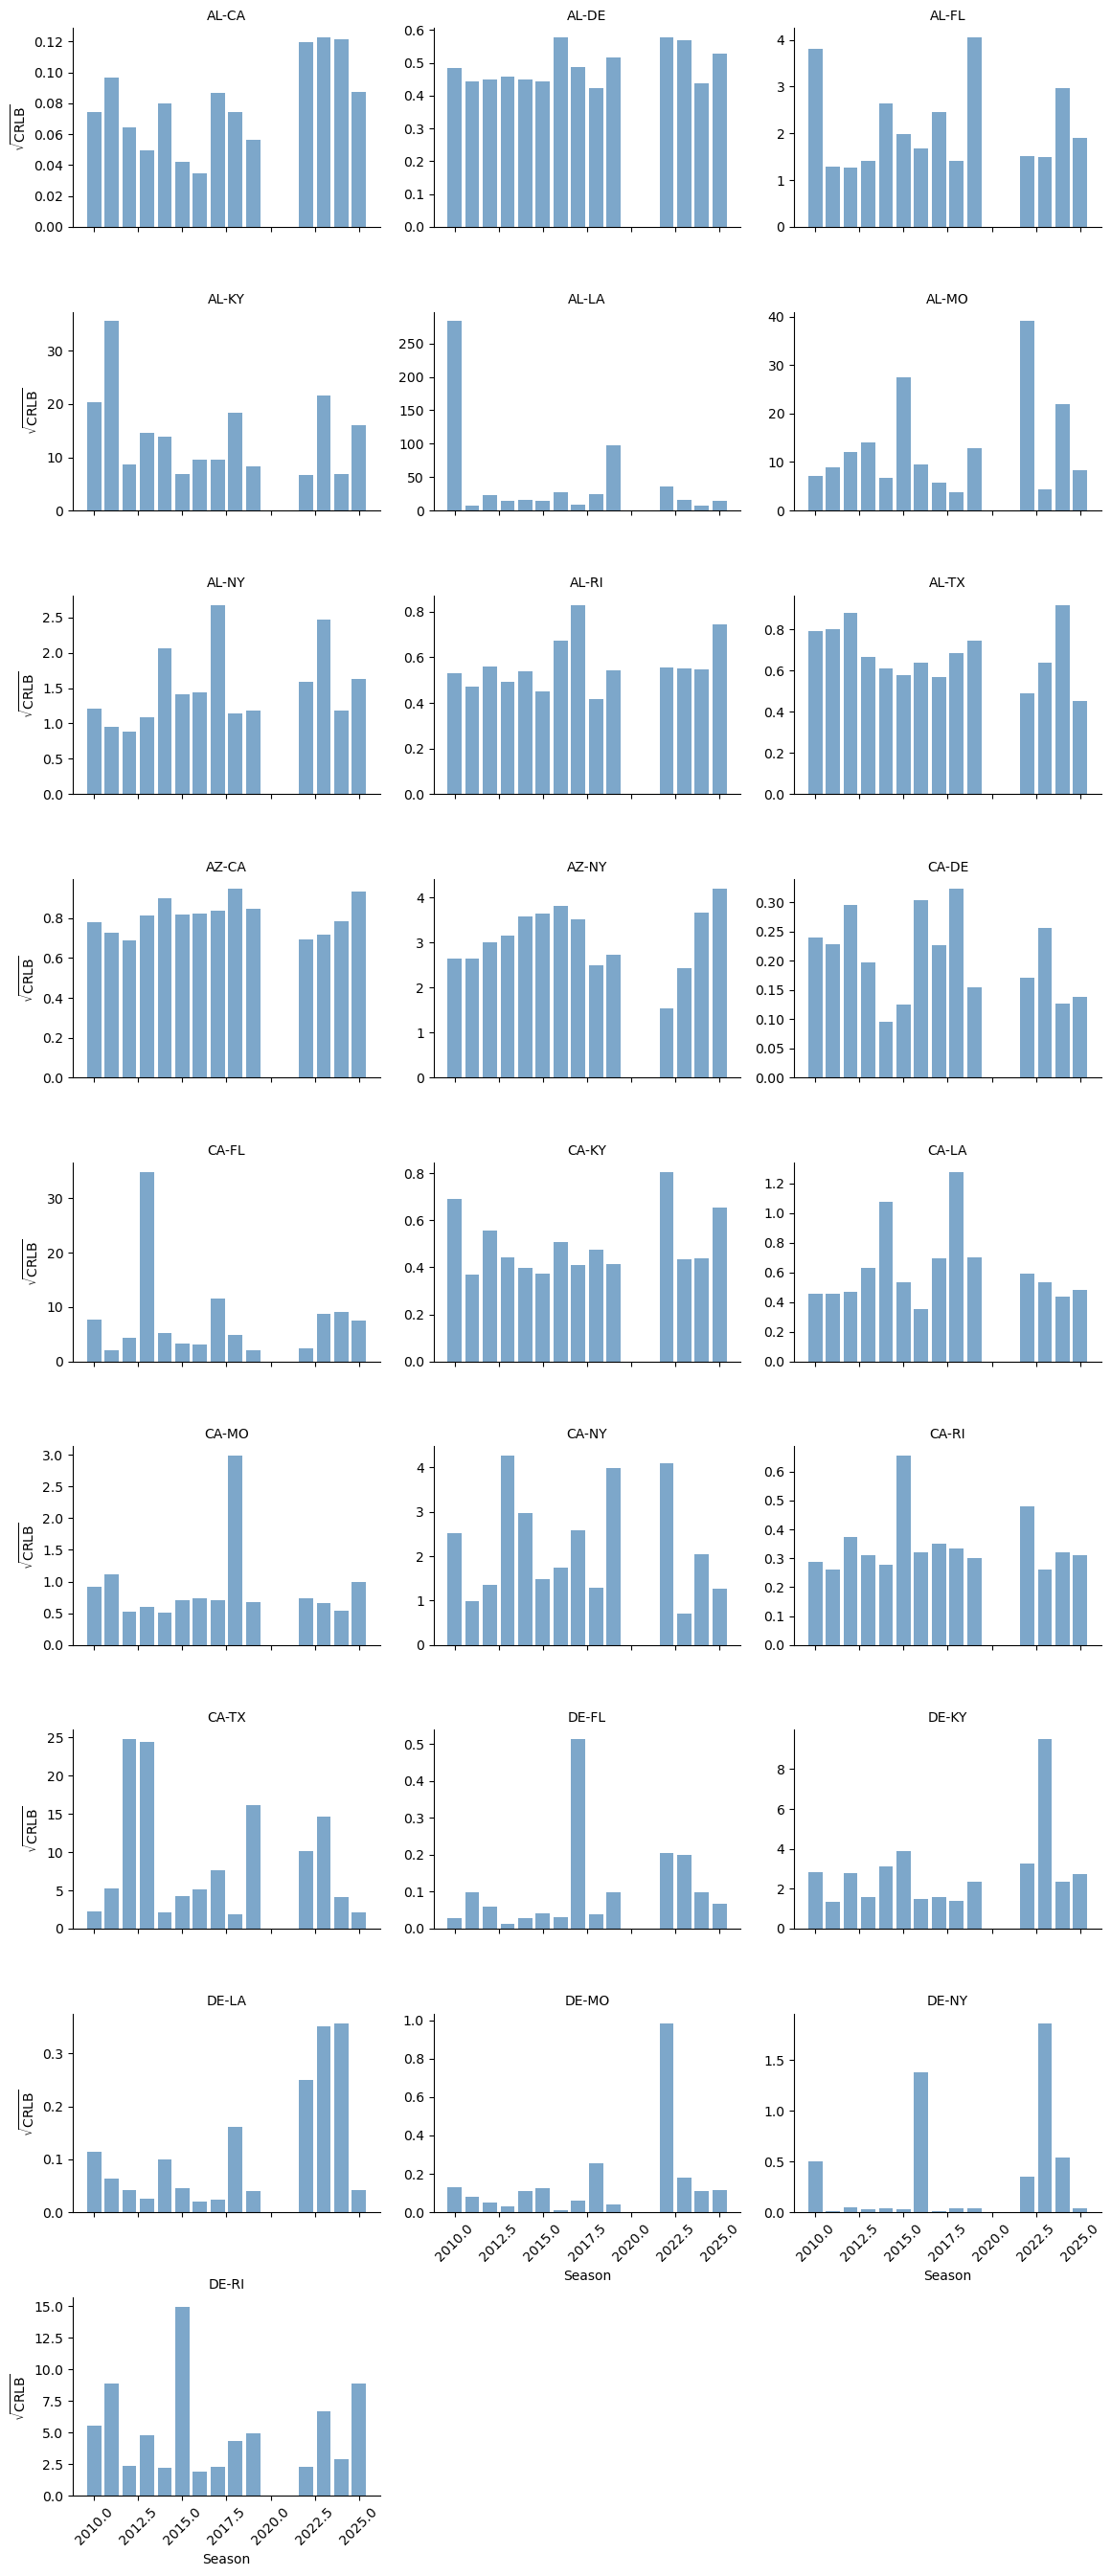

In [57]:
# Cell 6: CRLB by Season for Each State Pair
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

files = sorted(glob("outputs/states/*.csv"))
if files:
    all_res = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    all_res['pair'] = all_res['state1'] + '-' + all_res['state2']
    all_res['crlb_std'] = np.sqrt(all_res['crlb'])

    g = sns.FacetGrid(all_res, col='pair', col_wrap=3, height=3, aspect=1.3, sharey=False)
    g.map(plt.bar, 'season', 'crlb_std', color='steelblue', alpha=0.7)
    g.set_axis_labels('Season', r'$\sqrt{\mathrm{CRLB}}$')
    g.set_titles('{col_name}')
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig("pix/crlb_by_season.png", dpi=150, bbox_inches='tight')
    plt.savefig("pix/crlb_by_season.pdf", bbox_inches='tight')
    plt.show()
else:
    print("No results files found in outputs/states/")

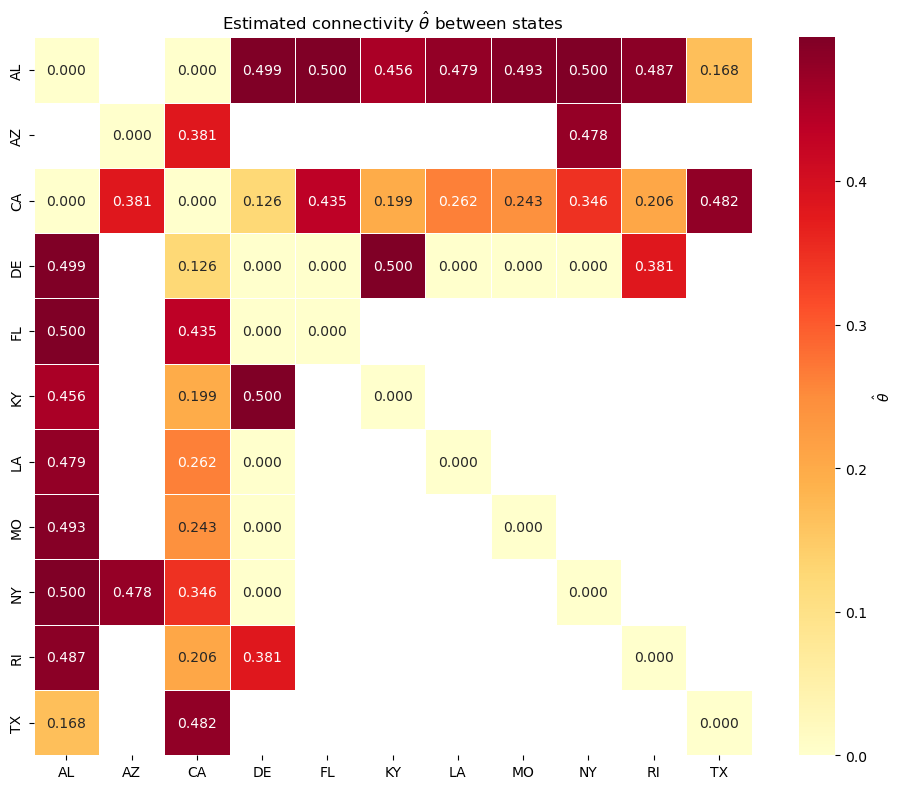

In [58]:
# Cell 7: Connectivity Heatmap across State Pairs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

files = sorted(glob("outputs/states/*.csv"))
if files:
    all_res = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    # One theta per pair
    theta_df = all_res.groupby(['state1', 'state2'])['theta'].first().reset_index()

    # Build symmetric matrix
    all_states = sorted(set(theta_df['state1']) | set(theta_df['state2']))
    mat = pd.DataFrame(np.nan, index=all_states, columns=all_states)
    for _, row in theta_df.iterrows():
        mat.loc[row['state1'], row['state2']] = row['theta']
        mat.loc[row['state2'], row['state1']] = row['theta']
    np.fill_diagonal(mat.values, 0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(mat.astype(float), cmap='YlOrRd', annot=True, fmt='.3f',
                square=True, linewidths=0.5, cbar_kws={'label': r'$\hat{\theta}$'})
    plt.title(r'Estimated connectivity $\hat{\theta}$ between states')
    plt.tight_layout()
    plt.savefig("pix/theta_heatmap.png", dpi=150, bbox_inches='tight')
    plt.savefig("pix/theta_heatmap.pdf", bbox_inches='tight')
    plt.show()
else:
    print("No results files found in outputs/states/")